# Naive Bayes Classifier — An Illustrated Tour

> Naive Bayes uses **Bayes' theorem** to compute the probability of each class given the features — making the "naive" assumption that features are conditionally independent given the class.

---

**What we cover:**
- Bayes' theorem — prior, likelihood, posterior
- The naive independence assumption
- Gaussian Naive Bayes — modeling feature likelihoods
- How the decision boundary forms
- Effect of class priors
- Metrics — confusion matrix, ROC

## The picture — per-feature class-conditional densities multiplied together

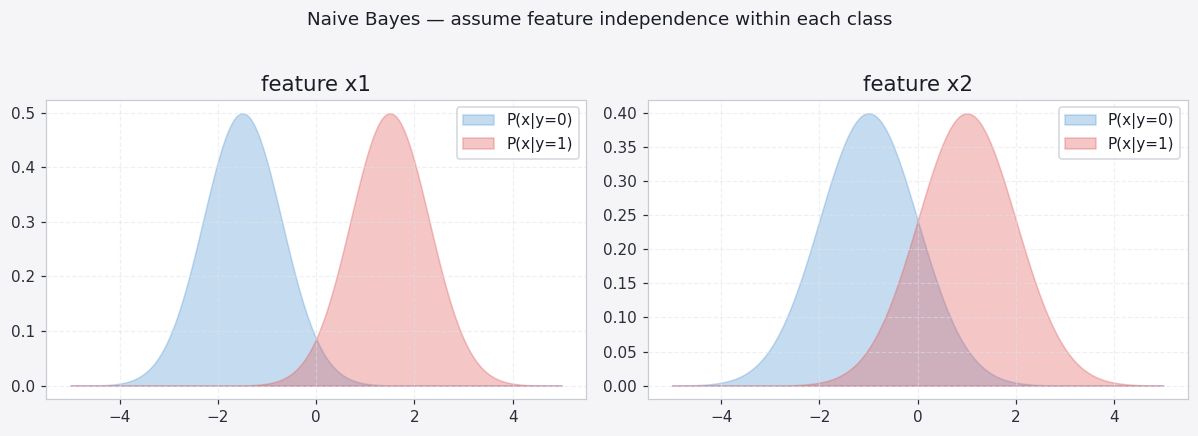

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
x = np.linspace(-5, 5, 400)
def nrm(m, s): return np.exp(-(x-m)**2/(2*s*s))/(s*np.sqrt(2*np.pi))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, mu1, mu2, ttl in zip(axes, [(-1.5,1.5),(-1.0,1.0)], [(0.8,0.8),(1.0,1.0)],
                              ['feature x1', 'feature x2']):
    ax.fill_between(x, nrm(mu1[0], mu2[0]), alpha=0.35, color=P[0], label='P(x|y=0)')
    ax.fill_between(x, nrm(mu1[1], mu2[1]), alpha=0.35, color=P[1], label='P(x|y=1)')
    ax.set_title(ttl); ax.legend(); ax.grid(True)
fig.suptitle('Naive Bayes — assume feature independence within each class', y=1.03)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

np.random.seed(42)
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, random_state=5,
                              n_clusters_per_class=1)

X, y = make_classification(n_samples=200, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print('Datasets ready')

Datasets ready


---
## Bayes' Theorem for Classification

For each class $k$, Bayes' theorem gives:

$$P(y=k \mid x) = \frac{P(x \mid y=k)\; P(y=k)}{P(x)}$$

| Term | Name | Meaning |
|---|---|---|
| $P(y=k)$ | **Prior** | How common is class $k$ before seeing $x$? |
| $P(x \mid y=k)$ | **Likelihood** | How probable is $x$ if the class is $k$? |
| $P(y=k \mid x)$ | **Posterior** | Updated probability after observing $x$ |

We predict the class with the highest posterior.

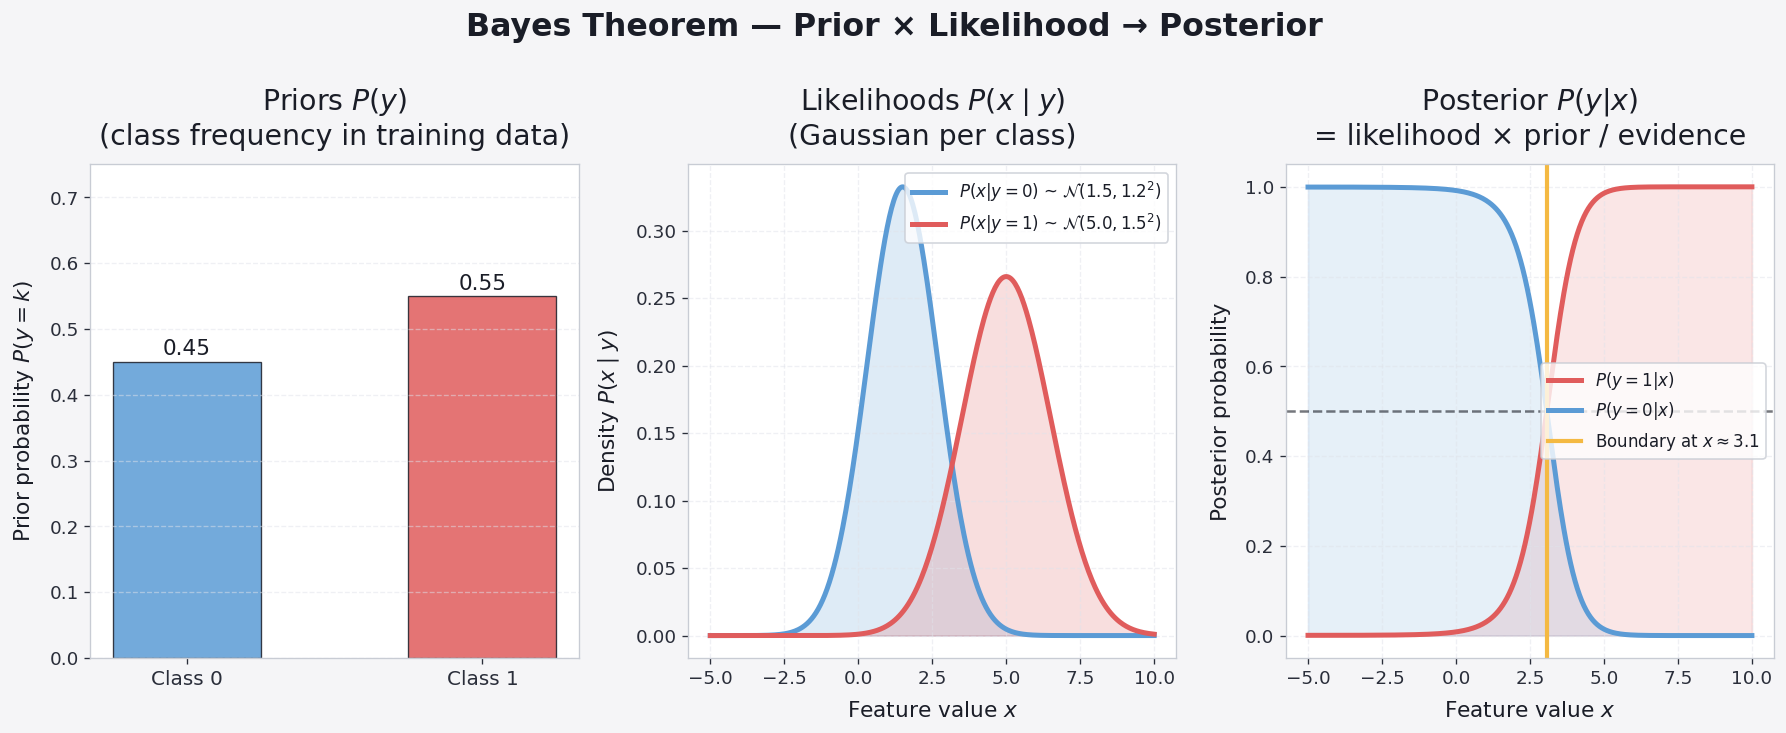

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

x_range = np.linspace(-5, 10, 400)

# Class conditional distributions (1D example)
mu0, sig0 = 1.5, 1.2
mu1, sig1 = 5.0, 1.5
phi0, phi1 = 0.45, 0.55   # class priors

like0 = norm.pdf(x_range, mu0, sig0)
like1 = norm.pdf(x_range, mu1, sig1)

# Left: priors
ax = axes[0]
ax.bar([0, 1], [phi0, phi1], color=[C0, C1], edgecolor='#1a1d27', lw=0.8, width=0.5, alpha=0.85)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Class 0', 'Class 1'], fontsize=12)
ax.set_ylabel('Prior probability $P(y=k)$', labelpad=8)
ax.set_title('Priors $P(y)$\n(class frequency in training data)', pad=12)
for val, x_pos, col in zip([phi0, phi1], [0, 1], [C0, C1]):
    ax.text(x_pos, val + 0.01, f'{val:.2f}', ha='center', fontsize=13, color='#1a1d27')
ax.set_ylim(0, 0.75); ax.grid(True, axis='y')

# Middle: likelihoods P(x|y)
ax = axes[1]
ax.plot(x_range, like0, color=C0, lw=3, label=f'$P(x|y=0)$ ~ $\\mathcal{{N}}({mu0},{sig0}^2)$')
ax.plot(x_range, like1, color=C1, lw=3, label=f'$P(x|y=1)$ ~ $\\mathcal{{N}}({mu1},{sig1}^2)$')
ax.fill_between(x_range, like0, alpha=0.20, color=C0)
ax.fill_between(x_range, like1, alpha=0.20, color=C1)
ax.set_xlabel('Feature value $x$', labelpad=8)
ax.set_ylabel('Density $P(x \\mid y)$', labelpad=8)
ax.set_title('Likelihoods $P(x \\mid y)$\n(Gaussian per class)', pad=12)
ax.legend(loc='upper right', fontsize=10); ax.grid(True)

# Right: posterior P(y|x)
ax = axes[2]
px     = like0 * phi0 + like1 * phi1  # evidence
post0  = (like0 * phi0) / (px + 1e-12)
post1  = (like1 * phi1) / (px + 1e-12)

ax.plot(x_range, post1, color=C1, lw=3, label='$P(y=1|x)$')
ax.plot(x_range, post0, color=C0, lw=3, label='$P(y=0|x)$')
ax.fill_between(x_range, 0, post1, alpha=0.15, color=C1)
ax.fill_between(x_range, 0, post0, alpha=0.15, color=C0)
ax.axhline(0.5, color='#1a1d27', ls='--', lw=1.5, alpha=0.6)
# Decision boundary
db_x = x_range[np.argmin(np.abs(post0 - post1))]
ax.axvline(db_x, color=CB, lw=2.5, label=f'Boundary at $x \\approx {db_x:.1f}$')
ax.set_xlabel('Feature value $x$', labelpad=8)
ax.set_ylabel('Posterior probability', labelpad=8)
ax.set_title('Posterior $P(y|x)$\n= likelihood × prior / evidence', pad=12)
ax.legend(loc='center right', fontsize=10); ax.grid(True)

fig.suptitle('Bayes Theorem — Prior × Likelihood → Posterior', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Naive Assumption

With $n$ features, computing $P(x \mid y=k)$ requires modelling the full joint distribution — expensive.

**Naive Bayes assumes features are conditionally independent given the class:**
$$P(x \mid y=k) = \prod_{j=1}^n P(x_j \mid y=k)$$

This means we only need to fit **one 1-D distribution per feature per class** — fast and simple.

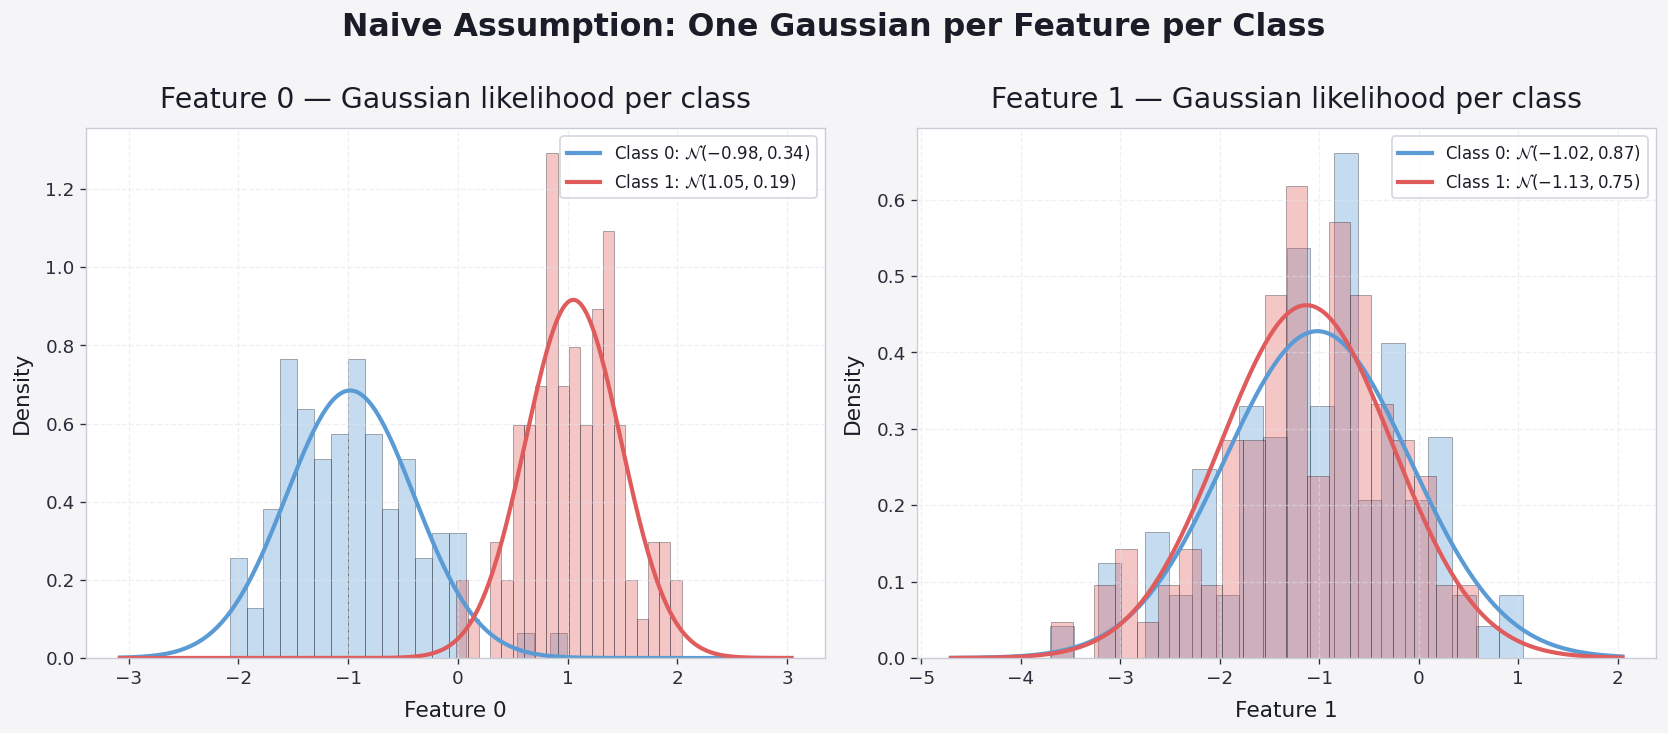

In [4]:
gnb = GaussianNB()
gnb.fit(X2, y2)

# Show per-feature Gaussians for the 2D dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for feat_idx, ax in enumerate(axes):
    x_feat = np.linspace(X2[:,feat_idx].min()-1, X2[:,feat_idx].max()+1, 300)
    for cls, col, lbl in [(0, C0, 'Class 0'), (1, C1, 'Class 1')]:
        mask = y2 == cls
        mu_c  = gnb.theta_[cls, feat_idx]
        var_c = gnb.var_[cls, feat_idx]
        ax.hist(X2[mask, feat_idx], bins=20, density=True,
                color=col, alpha=0.35, edgecolor='#1a1d27', lw=0.6)
        ax.plot(x_feat, norm.pdf(x_feat, mu_c, np.sqrt(var_c)),
                color=col, lw=2.5,
                label=f'{lbl}: $\\mathcal{{N}}({mu_c:.2f}, {var_c:.2f})$')
    ax.set_xlabel(f'Feature {feat_idx}', labelpad=8)
    ax.set_ylabel('Density', labelpad=8)
    ax.set_title(f'Feature {feat_idx} — Gaussian likelihood per class', pad=12)
    ax.legend(loc='upper right', fontsize=10); ax.grid(True)

fig.suptitle('Naive Assumption: One Gaussian per Feature per Class',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Decision Boundary and Effect of Priors

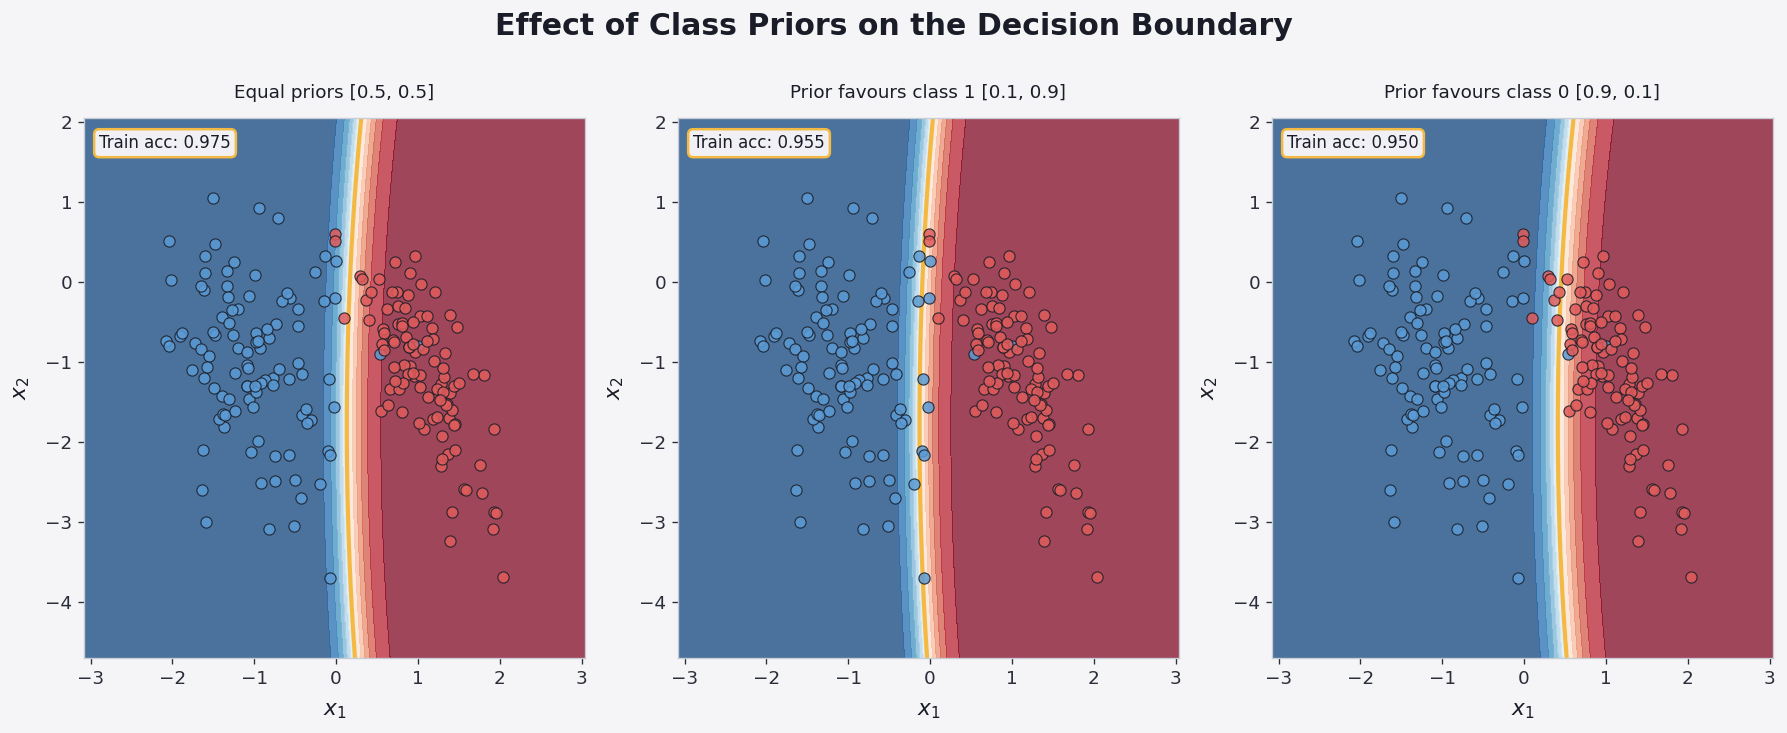

In [5]:
xx2, yy2 = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                        np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

prior_configs = [
    ([0.5, 0.5], 'Equal priors [0.5, 0.5]'),
    ([0.1, 0.9], 'Prior favours class 1 [0.1, 0.9]'),
    ([0.9, 0.1], 'Prior favours class 0 [0.9, 0.1]'),
]

for ax, (priors, title) in zip(axes, prior_configs):
    gnb_p = GaussianNB(priors=priors)
    gnb_p.fit(X2, y2)
    ZZ_p = gnb_p.predict_proba(np.c_[xx2.ravel(), yy2.ravel()])[:,1].reshape(xx2.shape)
    ax.contourf(xx2, yy2, ZZ_p, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(xx2, yy2, ZZ_p, levels=[0.5], colors=CB, linewidths=2.5)
    ax.scatter(X2[y2==0,0], X2[y2==0,1], c=C0, s=45, edgecolors='#1a1d27', lw=0.7, alpha=0.85, zorder=4)
    ax.scatter(X2[y2==1,0], X2[y2==1,1], c=C1, s=45, edgecolors='#1a1d27', lw=0.7, alpha=0.85, zorder=4)
    acc = accuracy_score(y2, gnb_p.predict(X2))
    ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
    ax.set_title(title, pad=12, fontsize=11); ax.grid(False)
    ax.text(0.03, 0.97, f'Train acc: {acc:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CB, lw=1.5))

fig.suptitle('Effect of Class Priors on the Decision Boundary',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

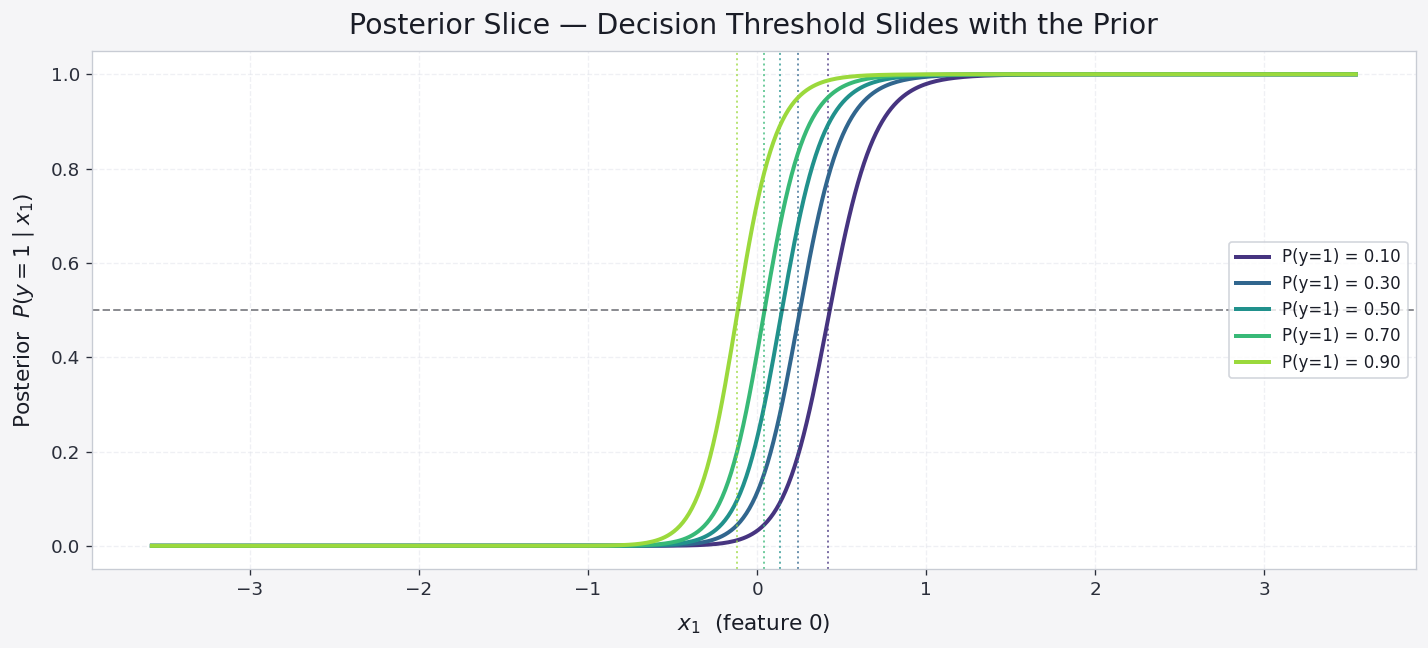

In [6]:
from sklearn.naive_bayes import GaussianNB as _GNB_post
_gnb_post = _GNB_post().fit(X2, y2)
_mu_nb  = _gnb_post.theta_
_var_nb = _gnb_post.var_

# Per-feature posterior slice along x_1, for several priors
_x_grid = np.linspace(X2[:, 0].min() - 1.5, X2[:, 0].max() + 1.5, 400)
_like0  = norm.pdf(_x_grid, _mu_nb[0, 0], np.sqrt(_var_nb[0, 0]))
_like1  = norm.pdf(_x_grid, _mu_nb[1, 0], np.sqrt(_var_nb[1, 0]))

_priors_curve = [0.10, 0.30, 0.50, 0.70, 0.90]
_cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, p in enumerate(_priors_curve):
    evid  = _like0 * (1 - p) + _like1 * p
    post1 = _like1 * p / (evid + 1e-12)
    col   = _cmap(0.15 + 0.7 * i / (len(_priors_curve) - 1))
    ax.plot(_x_grid, post1, color=col, lw=2.4, label=f'P(y=1) = {p:.2f}')
    # Decision threshold where post1 crosses 0.5
    sign = np.where(np.diff(np.sign(post1 - 0.5)))[0]
    if len(sign):
        db = _x_grid[sign[0]]
        ax.axvline(db, color=col, ls=':', lw=1.2, alpha=0.7)

ax.axhline(0.5, color='#1a1d27', ls='--', lw=1.2, alpha=0.5)
ax.set_xlabel('$x_1$  (feature 0)', labelpad=8)
ax.set_ylabel('Posterior  $P(y=1 \\mid x_1)$', labelpad=8)
ax.set_title('Posterior Slice — Decision Threshold Slides with the Prior',
             pad=10)
ax.legend(loc='center right', fontsize=10); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Metrics — Confusion Matrix & ROC

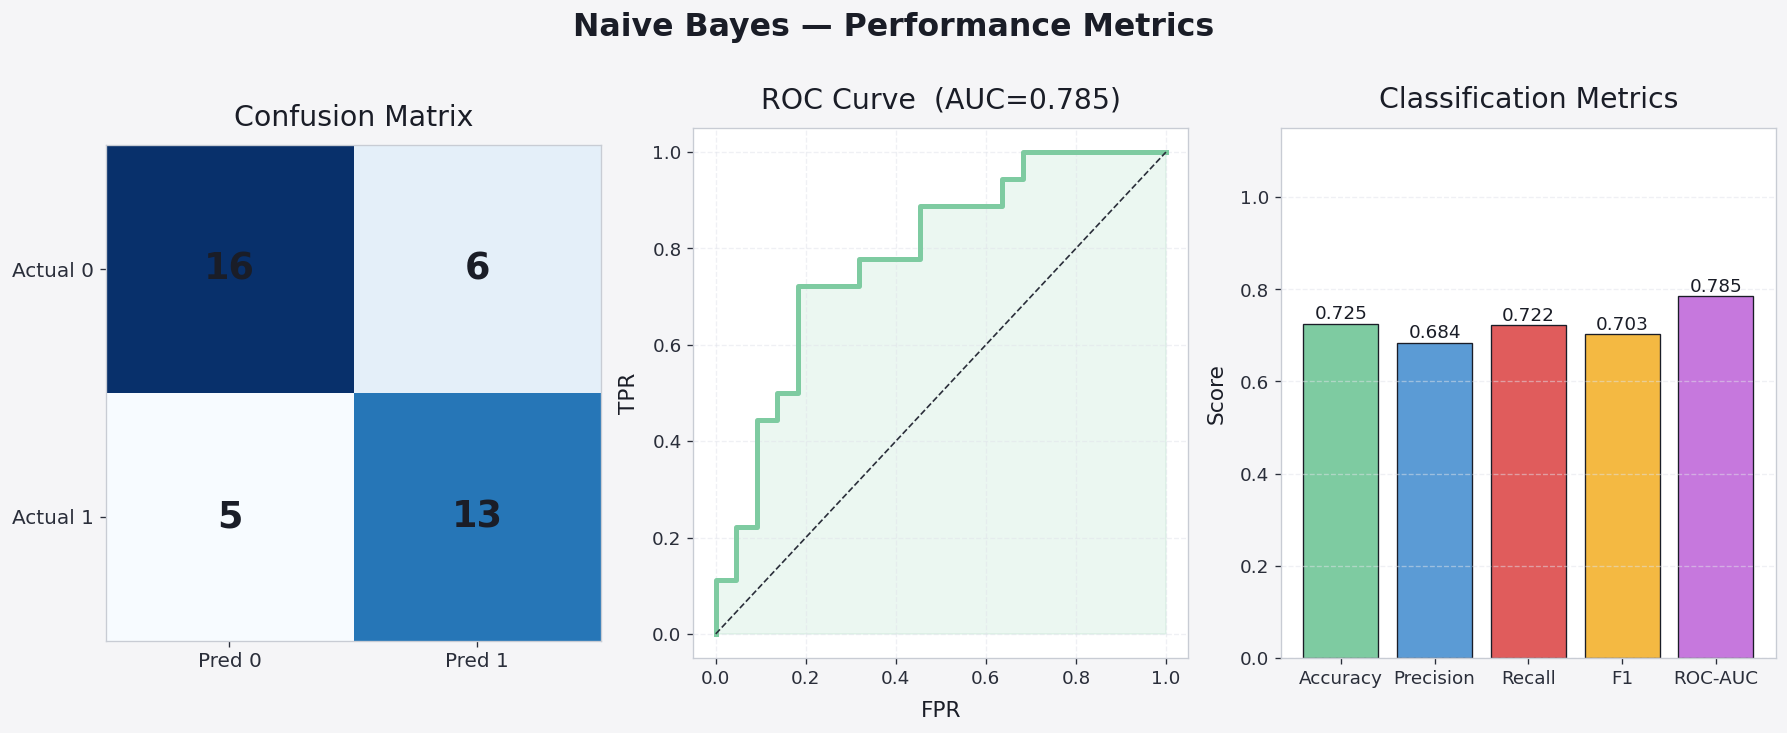

In [7]:
gnb_final = GaussianNB()
gnb_final.fit(X_tr, y_tr)
preds   = gnb_final.predict(X_te)
probs   = gnb_final.predict_proba(X_te)[:,1]
cm      = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

ax = axes[0]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title('Confusion Matrix', pad=12)

ax = axes[1]
ax.plot(fpr, tpr, color=CM, lw=3)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title(f'ROC Curve  (AUC={roc_auc:.3f})', pad=12); ax.grid(True)

ax = axes[2]
metrics_vals = {
    'Accuracy':  accuracy_score(y_te, preds),
    'Precision': precision_score(y_te, preds),
    'Recall':    recall_score(y_te, preds),
    'F1':        f1_score(y_te, preds),
    'ROC-AUC':   roc_auc,
}
bars = ax.bar(list(metrics_vals.keys()), list(metrics_vals.values()),
              color=[CM, C0, C1, CB, CP], edgecolor='#1a1d27', lw=0.8)
for bar, val in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', labelpad=8)
ax.set_title('Classification Metrics', pad=12); ax.grid(True, axis='y')

fig.suptitle('Naive Bayes — Performance Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

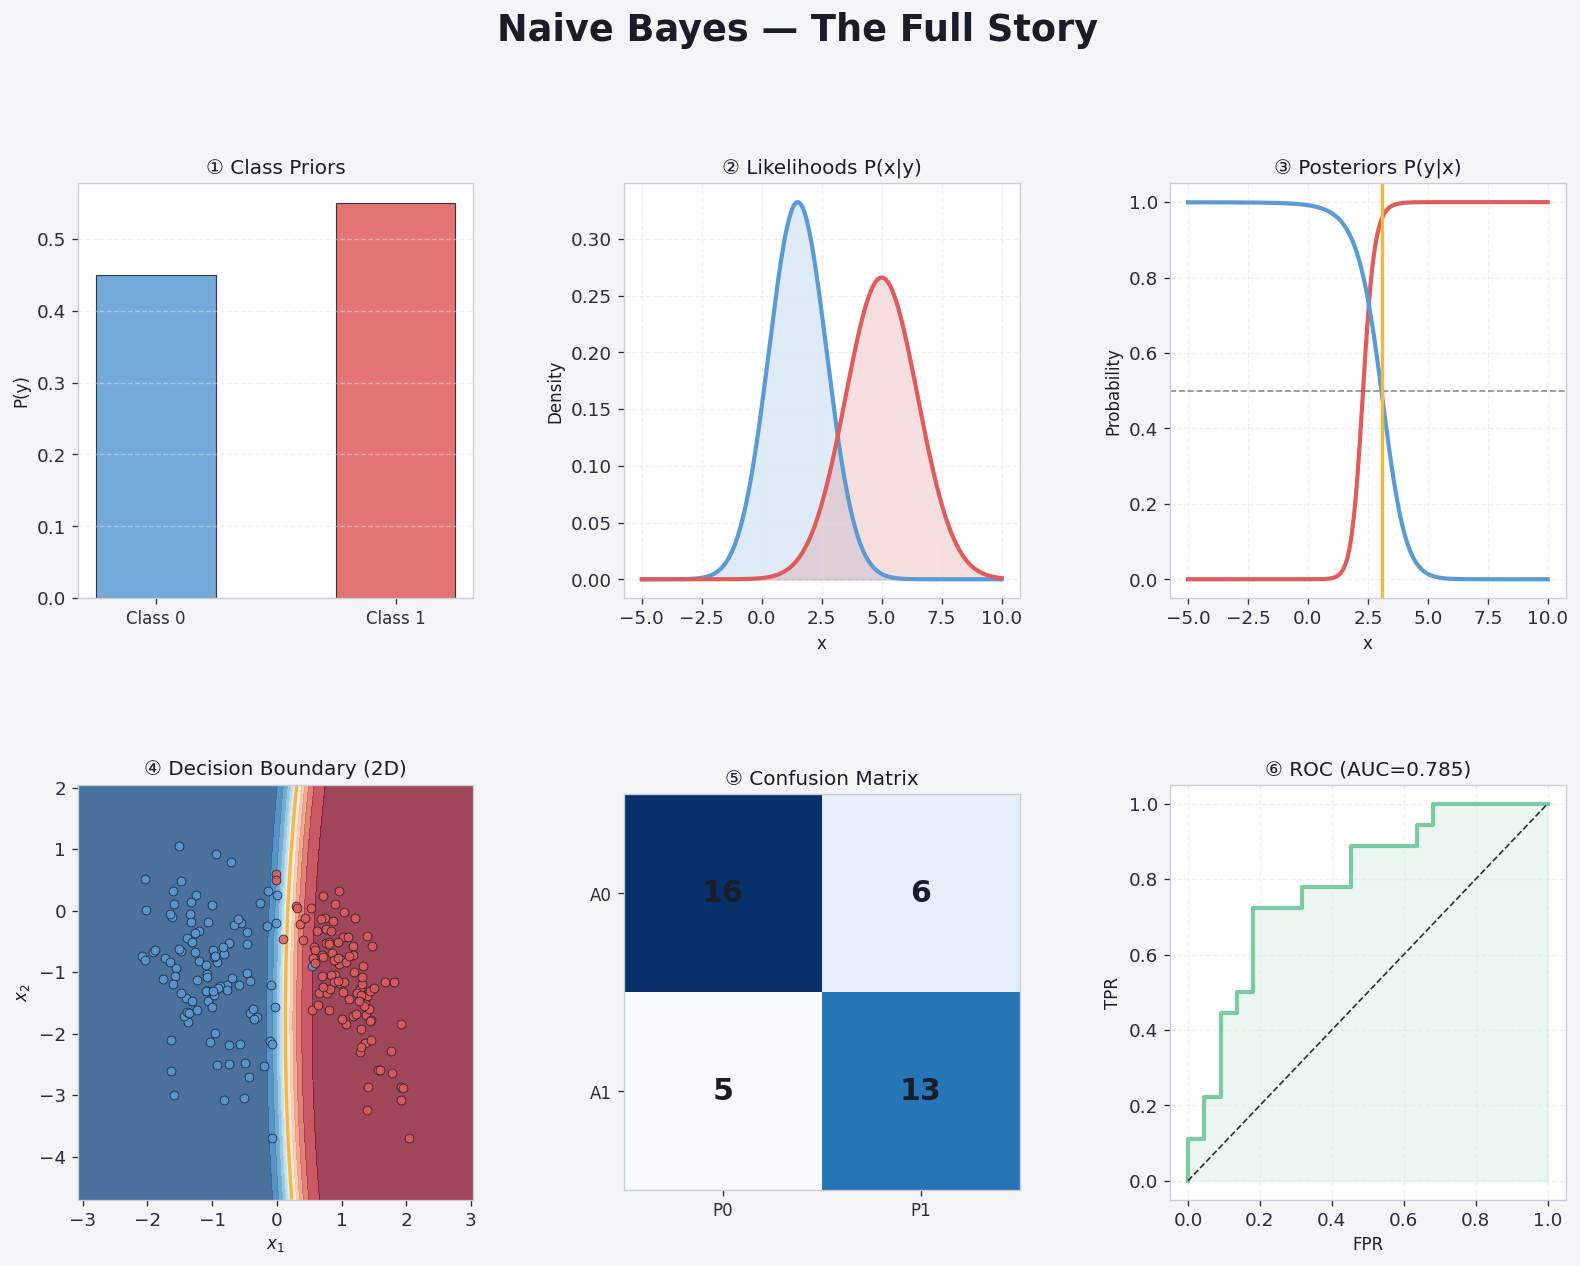

In [8]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax=fig.add_subplot(gs[0,0])
ax.bar([0,1],[phi0,phi1],color=[C0,C1],edgecolor='#1a1d27',lw=0.7,width=0.5,alpha=0.85)
ax.set_xticks([0,1]);ax.set_xticklabels(['Class 0','Class 1'],fontsize=10)
ax.set_title('① Class Priors',fontsize=12);ax.set_ylabel('P(y)',fontsize=10);ax.grid(True,axis='y')

ax=fig.add_subplot(gs[0,1])
ax.plot(x_range,like0,color=C0,lw=2.5)
ax.plot(x_range,like1,color=C1,lw=2.5)
ax.fill_between(x_range,like0,alpha=0.20,color=C0)
ax.fill_between(x_range,like1,alpha=0.20,color=C1)
ax.set_title('② Likelihoods P(x|y)',fontsize=12)
ax.set_xlabel('x',fontsize=10);ax.set_ylabel('Density',fontsize=10);ax.grid(True)

ax=fig.add_subplot(gs[0,2])
ax.plot(x_range,post1,color=C1,lw=2.5)
ax.plot(x_range,post0,color=C0,lw=2.5)
ax.axhline(0.5,color='#1a1d27',ls='--',lw=1,alpha=0.5)
ax.axvline(db_x,color=CB,lw=2)
ax.set_title('③ Posteriors P(y|x)',fontsize=12)
ax.set_xlabel('x',fontsize=10);ax.set_ylabel('Probability',fontsize=10);ax.grid(True)

gnb_eq=GaussianNB(priors=[0.5,0.5]);gnb_eq.fit(X2,y2)
ZZeq=gnb_eq.predict_proba(np.c_[xx2.ravel(),yy2.ravel()])[:,1].reshape(xx2.shape)
ax=fig.add_subplot(gs[1,0])
ax.contourf(xx2,yy2,ZZeq,levels=15,cmap='RdBu_r',alpha=0.75)
ax.contour(xx2,yy2,ZZeq,levels=[0.5],colors=CB,linewidths=2)
ax.scatter(X2[y2==0,0],X2[y2==0,1],c=C0,s=28,edgecolors='#1a1d27',lw=0.5,alpha=0.85,zorder=4)
ax.scatter(X2[y2==1,0],X2[y2==1,1],c=C1,s=28,edgecolors='#1a1d27',lw=0.5,alpha=0.85,zorder=4)
ax.set_title('④ Decision Boundary (2D)',fontsize=12)
ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax=fig.add_subplot(gs[1,1])
ax.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(['P0','P1'],fontsize=10);ax.set_yticklabels(['A0','A1'],fontsize=10)
ax.set_title('⑤ Confusion Matrix',fontsize=12)

ax=fig.add_subplot(gs[1,2])
ax.plot(fpr,tpr,color=CM,lw=2.5);ax.fill_between(fpr,tpr,alpha=0.15,color=CM)
ax.plot([0,1],[0,1],color='#2a2e3a',ls='--',lw=1)
ax.set_title(f'⑥ ROC (AUC={roc_auc:.3f})',fontsize=12)
ax.set_xlabel('FPR',fontsize=10);ax.set_ylabel('TPR',fontsize=10);ax.grid(True)

fig.suptitle('Naive Bayes — The Full Story',fontsize=22,fontweight='bold',color='#1a1d27',y=1.01)
plt.show()

---
## ⚖️ When to use Naive Bayes — and when not to

| Situation | Naive Bayes | Logistic | GDA | Tree |
|---|---|---|---|---|
| Lots of features, little data | ✅ very fast | partial | ❌ | partial |
| Text / bag-of-words | ✅ Multinomial NB | ✅ | ❌ | ❌ |
| Strong feature dependencies | ❌ assumption broken | ✅ | ✅ | ✅ |
| Need calibrated probabilities | ❌ overconfident | ✅ | ✅ | partial |

> A surprisingly strong **baseline for text classification**, and the only generative model that scales gracefully to thousands of features.


---
## 🎯 Try this

1. **Laplace smoothing.** Set $\alpha=0$ and watch the model assign zero probability to any test word it never saw — then sweep $\alpha$ and observe the smoothing effect.
2. **Calibration.** NB probabilities are notoriously overconfident. Plot a reliability diagram and apply Platt scaling — accuracy stays similar; calibration improves.
3. **Independence check.** Compute the $\chi^2$ statistic between feature pairs given the class. The features with the strongest dependence are exactly where NB hurts.


---
## Summary

| Concept | Formula | Key Insight |
|---|---|---|
| Bayes rule | $P(y\lvert x) \propto P(x\lvert y)\,P(y)$ | Posterior ∝ likelihood × prior |
| Naive assumption | $P(x\lvert y) = \prod_j P(x_j\lvert y)$ | Features independent given class — simplifies fitting |
| Gaussian NB | $P(x_j\lvert y=k) = \mathcal{N}(\mu_{kj},\,\sigma_{kj}^2)$ | One mean and variance per feature per class |
| Decision rule | Predict $\arg\max_k P(y=k\lvert x)$ | Class with highest posterior |
| Prior effect | Shifts boundary toward rarer class | Use when class imbalance is known |
| Strengths | Fast, works well with small data | Surprisingly competitive despite naive assumption |
| Weaknesses | Independence assumption often violated | Correlated features hurt performance |

**Key insight:** despite the "naive" independence assumption being almost always violated in practice, Gaussian Naive Bayes often works surprisingly well — especially on high-dimensional data with few training examples. It's fast to train, requires no hyperparameter tuning, and naturally handles multi-class problems.